# Machine Learning Essentials SS25 - Exercise Sheet 9

## Proposed Solutions - Exercise 3

In [35]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.means import Mean
from torch.optim import Adam

In [36]:
# Search Area Config
GRID_SIZE = 50
# "Secret" location of the wreckage.
TRUE_WRECKAGE_LOCATION = (42, 42)
# Center of our initial prior belief.
PRIOR_CENTER = (25, 25)
PRIOR_WIDTH = 10.0
# Create coordinate grid of the "ocean" to search.
xx, yy = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE))
grid_coords = torch.tensor(np.vstack([xx.ravel(), yy.ravel()]).T, dtype=torch.float)

In [37]:
# Search environment
# You're given 2 key components:
# The prior belief map, which is a 2D Gaussian blob representing our initial, uncertain guess about the wreckage location. This will be used as the prior mean for our GP.
# The search function, which is a function that simulates a noisy sonar measurement. It returns a strong signal near the wreckage and a weak, noisy signal far away.

def create_prior_map(center, width):
    """Creates a 2D Gaussian blob as our prior belief."""
    dist_sq = (xx - center[0])**2 + (yy - center[1])**2
    prior_map = np.exp(-dist_sq / (2 * width**2))
    return torch.tensor(prior_map, dtype=torch.float)

def create_search_function(wreckage_loc=TRUE_WRECKAGE_LOCATION, amplitude=10.0, signal_width=4.0, noise_level=0.5):
    " Create a noisy search function with a hidden target."""
    true_x, true_y = wreckage_loc
    
    def search(x, y):
        """Simulates a noisy sonar reading at a given coordinate."""
        dist_sq = (x - true_x)**2 + (y - true_y)**2
        signal = amplitude * np.exp(-dist_sq / (2 * signal_width**2))
        noise = np.random.normal(0, noise_level) # Measurement noise
        return signal + noise
    
    return search

prior_belief_map = create_prior_map(PRIOR_CENTER, PRIOR_WIDTH)
perform_search = create_search_function(TRUE_WRECKAGE_LOCATION)

In [38]:
class PriorMean(gpytorch.means.Mean):
    """A GP mean function that uses a pre-defined prior map."""
    def __init__(self, prior_map):
        super().__init__()
        self.register_buffer('prior_map', prior_map) # This allows the prior map to be part of the model's state, so it's accessible during training and inference.

    def forward(self, input):
        # TODO: Define a custom mean function for your GP that uses the prior belief map.
        x = input[:, 0].clamp(0, self.prior_map.shape[1] - 1)
        y = input[:, 1].clamp(0, self.prior_map.shape[0] - 1)
        x_idx = x.round().long()
        y_idx = y.round().long()
        return self.prior_map[y_idx, x_idx]

class BayesianSearchGP(gpytorch.models.ExactGP):
    """Our GP model for the search, incorporating the prior belief map."""
    def __init__(self, train_x, train_y, likelihood, prior_map):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = PriorMean(prior_map)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [39]:
# TODO: Implement an acquisition function for the Bayesian search.
def acquisition_function(X, gp, beta=2.0):
    mu, sigma = gp.predict(X, return_std=True)
    return mu + beta * sigma

In [40]:
# Bayesian Search loop
# This is the main loop where the agent iteratively searches the ocean.
# In each step:
# 1.  Fit the GP to all observations made so far.
# 2.  Use the UCB acquisition function to decide where to search next.
# 3.  Call `perform_search` to get a new observation.
# 4.  Add the new data to the agent's dataset.

# Initialization
# Start with no data
train_x = torch.empty(0, 2, dtype=torch.float)
train_y = torch.empty(0, dtype=torch.float)

# TODO: Instantiate the GP model (with the prior belief map), the GaussianLikelihood, and the optimizer (use e.g. Adam with an appropriate learning rate).
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = BayesianSearchGP(train_x, train_y, likelihood, prior_belief_map)
optimizer = Adam(model.parameters(), lr=0.1)

#TODO: Define the marginal log likelihood (mll) for the GP model.
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# Search parameters
N_SEARCHES = 30
search_history = []
posterior_mean_history = []

for i in tqdm(range(N_SEARCHES)):
    if i > 0:
        model.train()
        likelihood.train()
        for j in range(50): # TODO: Fit the GP model for a few epochs
            # --> Zero gradients, forward pass, calculate loss, backward pass, and optimize
            optimizer.zero_grad()
            output = model(train_x)
            loss = -mll(output, train_y)
            loss.backward()
            optimizer.step()

    model.eval()
    likelihood.eval()
    with torch.no_grad():
        # TODO: Select the next point to search using your acquisition function. Then, choose the coordinates of the next point to search.
        posterior = model(grid_coords)
        mu = posterior.mean
        sigma = posterior.variance.sqrt()
        beta = 2.0
        acquisiton_function_values = mu + beta * sigma
        next_point_idx = torch.argmax(acquisiton_function_values)
        next_point_coords = grid_coords[next_point_idx]

    # TODO: Perform the search on the "candidate" point, chosen by your acquisition function
    x, y = next_point_coords.tolist()
    observation = perform_search(x, y)  # TODO: Perform the search
    
    # Store history for visualization
    search_history.append((x, y, observation))
    with torch.no_grad():
        posterior_mean_history.append(model(grid_coords).mean.view(GRID_SIZE, GRID_SIZE).numpy())

    # 4. Add new data to the dataset
    train_x = torch.cat([train_x, next_point_coords.view(1, 2)])
    train_y = torch.cat([train_y, torch.tensor([observation], dtype=torch.float)])
    model.set_train_data(train_x, train_y, strict=False)


100%|██████████| 30/30 [00:01<00:00, 21.07it/s]


In [41]:
# Use the following code to generate an animation of the Bayesian search process. You can play around with the parameters to make it more visually appealing if you like.

# Helper function for ocean background
def create_ocean_background(grid_size=50, noise_strength=0.1, noise_scale=5.0):
    gradient = np.tile(np.linspace(0, 1, grid_size), (grid_size, 1)).T
    noise = gaussian_filter(np.random.randn(grid_size, grid_size), sigma=noise_scale)
    return gradient + noise * noise_strength

# Animation setup
fig, ax = plt.subplots(figsize=(10, 8))
ocean_bg = create_ocean_background(GRID_SIZE)
def animate(frame):
    ax.clear()
    # Plot ocean background
    extent = [-0.5, GRID_SIZE - 0.5, -0.5, GRID_SIZE - 0.5] # Define extent to make visualization clearer
    ax.imshow(ocean_bg, cmap='ocean', origin='lower', extent=extent, zorder=-1)
    
    # Plot the belief map (GP posterior mean)
    belief_map = posterior_mean_history[frame]
    ax.contourf(xx, yy, belief_map, levels=15, cmap='Reds', alpha=0.6, zorder=1)
    
    # Plot search points
    points = np.array(search_history[:frame+1])
    sc = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], cmap='viridis', s=60, ec='black', zorder=2)
    
    # Highlight the current search
    ax.scatter(points[-1, 0], points[-1, 1], c='cyan', s=150, ec='black', marker='X', zorder=3, label='Current Search')
     
    # Show the true location
    ax.scatter(
        TRUE_WRECKAGE_LOCATION[0], TRUE_WRECKAGE_LOCATION[1], 
        c='lime', s=400, marker='*', ec='black', zorder=4, label='True Wreckage Location'
    )
    
    ax.set_title(f"Bayesian Search: Step {frame + 1}/{N_SEARCHES}", fontsize=16)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.legend(loc='upper left')
    ax.set_aspect('equal')

ani = FuncAnimation(fig, animate, frames=N_SEARCHES, interval=500, repeat=False)
plt.close(fig) # Prevent static plot from showing before the animation
HTML(ani.to_html5_video())

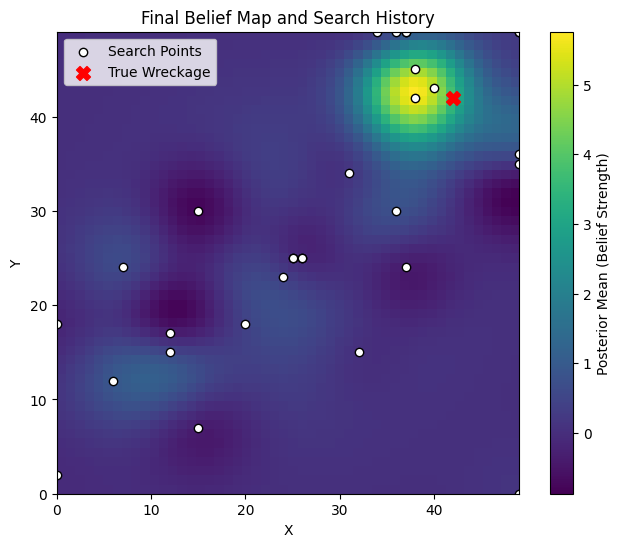

True wreckage location: (42.00, 42.00)
Final best guess:       (38.00, 43.00)
Distance error:         4.12 units


In [45]:
# TODO: Visualize the final belief map and search history, compare to true wreckage location

searched_x = [p[0] for p in search_history]
searched_y = [p[1] for p in search_history]


final_posterior_mean = posterior_mean_history[-1]

plt.figure(figsize=(8, 6))
plt.imshow(final_posterior_mean, extent=(0, GRID_SIZE-1, 0, GRID_SIZE-1), origin='lower', cmap='viridis')
plt.colorbar(label='Posterior Mean (Belief Strength)')
plt.scatter(searched_x, searched_y, c='white', edgecolor='black', label='Search Points')
plt.scatter(*TRUE_WRECKAGE_LOCATION, c='red', marker='X', s=100, label='True Wreckage')
plt.title("Final Belief Map and Search History")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(False)
plt.show()


# TODO: Print the true wreckage location, your search agent's final best guess, and the distance between them.
flat_posterior = final_posterior_mean.flatten()
best_guess_idx = np.argmax(flat_posterior)
best_guess_coords = grid_coords[best_guess_idx].tolist()


true_x, true_y = TRUE_WRECKAGE_LOCATION
guess_x, guess_y = best_guess_coords
distance = np.sqrt((true_x - guess_x)**2 + (true_y - guess_y)**2)


print(f"True wreckage location: ({true_x:.2f}, {true_y:.2f})")
print(f"Final best guess:       ({guess_x:.2f}, {guess_y:.2f})")
print(f"Distance error:         {distance:.2f} units")


**TODO**: Discuss your results.

In the animation we see that the guesses in the beginning look rather random but the get more precise after we have sonar readings that give us a better aproxmation for the position.